# F$SHN $YNC - Image Similarity Product Search

Goal: use product images and an uploaded outfit image to find visually similar fashion products from Egyptian stores.

In this notebook, I will:
- load the saved products catalogue
- check product image links
- prepare product images for AI image similarity
- later use image embeddings to find similar products

In [16]:
import pandas as pd
from pathlib import Path

current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

data_folder = project_root / "data"

products_df = pd.read_csv(data_folder / "products.csv")

products_df.head()

,product_name,store_name,product_url,image_url,category,color,fit,material,style,price_egp,...,black,colorful,baggy,fitted,sporty,leather,fur,modern,elegant,edgy
0,249 Code T-Shirt,balance_249,https://balancestudios.myshopify.com/products/...,https://balancestudios.myshopify.com/cdn/shop/...,t-shirt,dark red,boxy / oversized,unknown,streetwear,649,...,0,1,1,0,0,0,0,1,0,1
1,Frank Ocean White T-Shirt V3,ryfworld,https://rockyourfits.online/products/frank-oce...,https://rockyourfits.online/cdn/shop/files/AE7...,t-shirt,white,boxy,unknown,streetwear,630,...,0,0,1,0,0,0,0,1,0,1
2,The Lace Shirt,nh_designs,https://nhdesignss.com/product/the-lace-shirt/,https://nhdesignss.com/wp-content/uploads/2026...,shirt,black / brown / white,fitted,unknown,elegant,799,...,1,0,0,1,0,0,0,1,1,0


In [17]:
products_df[["product_name", "store_name", "product_url", "image_url", "price_egp"]]

,product_name,store_name,product_url,image_url,price_egp
0,249 Code T-Shirt,balance_249,https://balancestudios.myshopify.com/products/...,https://balancestudios.myshopify.com/cdn/shop/...,649
1,Frank Ocean White T-Shirt V3,ryfworld,https://rockyourfits.online/products/frank-oce...,https://rockyourfits.online/cdn/shop/files/AE7...,630
2,The Lace Shirt,nh_designs,https://nhdesignss.com/product/the-lace-shirt/,https://nhdesignss.com/wp-content/uploads/2026...,799


In [18]:
import requests #open link from the internet and get the content
from PIL import Image #بنستعملها لفتح الصور 
from io import BytesIO #بتحول البايتس لي صورة بايثون بيقدر يفتحها
from IPython.display import display #so photo show in the notebook

In [ ]:
first_image_url = products_df.loc[0 , "image_url"]

first_image_url

'https://balancestudios.myshopify.com/cdn/shop/files/818B21B9-614A-4F74-AE12-47D80CECB560.jpg?v=1780964851&width=493'

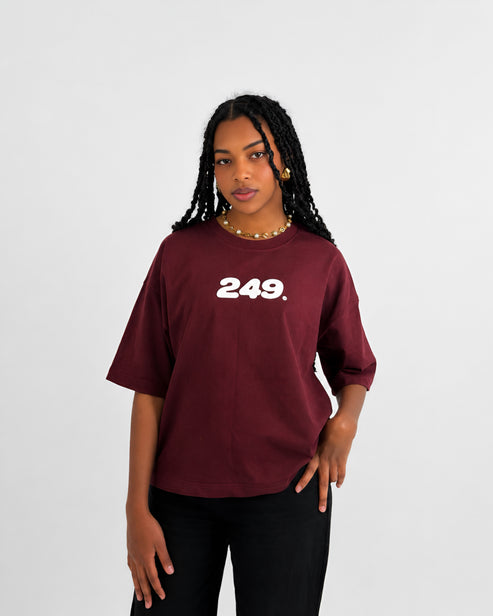

In [ ]:
response = requests.get(first_image_url)

product_image = PILImage.open(BytesIO(response.content))

display(product_image) # here to make sure that the first photo opens

In [ ]:
def load_image_from_url(image_url):
    response = requests.get(image_url)
    product_image = PILImage.open(BytesIO(response.content)).convert("RGB")
    #rgb نخلي الصورة بالوان موحدة  
    return product_image

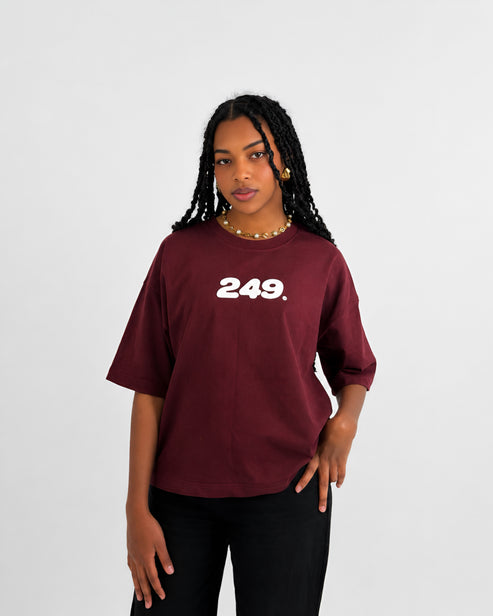

In [25]:
#testing the previous function 
test_image_url = products_df.loc[0,"image_url"]
test_image = load_image_from_url(test_image_url)

display(test_image)

0 249 Code T-Shirt - balance_249


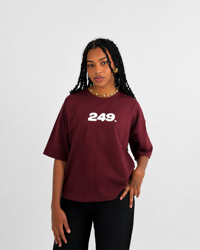

1 Frank Ocean White T-Shirt V3 - ryfworld


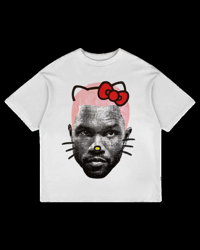

2 The Lace Shirt - nh_designs


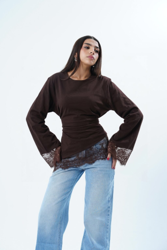

In [28]:
for index, row in products_df.iterrows():
    print(index,row["product_name"],"-",row["store_name"])

    Image = load_image_from_url(row["image_url"])

    small_image = Image.copy()
    small_image.thumbnail((250, 250))

    display(small_image)

In [31]:
%pip install torch transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
    --------------------------------------- 0.3/11.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.2 MB 1.4 MB/s eta 0:00:08
   -- ------------------------------------- 0.8/11.2 MB 1.4 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/11.2 MB 1.6 MB/s eta 0:00:07
   ------ --------------------------------- 1.8/11.2 MB 1.8 MB/s eta 0:00:06
   ------- -------------------------------- 2.1/11.2 MB 1.8 MB/s eta 0:00:06
   -------- ------------------------------- 2.4/11.2 MB 1.6 MB/s eta 0:00:06
   ---------- ----------------------------- 2.9/11.2 MB 1.8 MB/s eta 0:00:05
   ------------- -------------------------- 3.7/11.2 MB 2.0 MB/s eta 0:00:04
   --------------- ------------------------ 4.5/11.2 MB 2.2 MB/s eta 0:00:04
   ------------------ --------------------- 5.2/11.2 MB 2.3 MB/s eta 0:00:03
   --------------------- ------------------ 6.0/11.2 MB 2.4 MB/s eta 0:00:03
   ----------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
from transformers import CLIPProcessor, CLIPModel

In [4]:
model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(model_name)
clip_processor = CLIPProcessor.from_pretrained(model_name)

clip_model.eval()

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

c:\Users\rahaf\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rahaf\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1

In [17]:
def get_image_embedding(image):
    inputs = clip_processor(
        images=image,
        return_tensors="pt"
    )

    with torch.no_grad():
        vision_outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        pooled_output = vision_outputs.pooler_output

        image_features = clip_model.visual_projection(pooled_output)

    image_features = image_features / image_features.norm(
        dim=-1,
        keepdim=True
    )

    embedding = image_features.squeeze().numpy()

    return embedding

In [11]:
import pandas as pd
from pathlib import Path

current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

data_folder = project_root / "data"

products_df = pd.read_csv(data_folder / "products.csv")

products_df.head()

,product_name,store_name,product_url,image_url,category,color,fit,material,style,price_egp,...,black,colorful,baggy,fitted,sporty,leather,fur,modern,elegant,edgy
0,249 Code T-Shirt,balance_249,https://balancestudios.myshopify.com/products/...,https://balancestudios.myshopify.com/cdn/shop/...,t-shirt,dark red,boxy / oversized,unknown,streetwear,649,...,0,1,1,0,0,0,0,1,0,1
1,Frank Ocean White T-Shirt V3,ryfworld,https://rockyourfits.online/products/frank-oce...,https://rockyourfits.online/cdn/shop/files/AE7...,t-shirt,white,boxy,unknown,streetwear,630,...,0,0,1,0,0,0,0,1,0,1
2,The Lace Shirt,nh_designs,https://nhdesignss.com/product/the-lace-shirt/,https://nhdesignss.com/wp-content/uploads/2026...,shirt,black / brown / white,fitted,unknown,elegant,799,...,1,0,0,1,0,0,0,1,1,0


In [15]:
import requests
from PIL import Image as PILImage
from io import BytesIO

def load_image_from_url(image_url):
    response = requests.get(image_url)
    product_image = PILImage.open(BytesIO(response.content)).convert("RGB")
    return product_image

In [18]:
first_image_url = products_df.loc[0, "image_url"]

first_product_image = load_image_from_url(first_image_url)

first_embedding = get_image_embedding(first_product_image)

first_embedding.shape

(512,)

In [19]:
import numpy as np

In [20]:
product_embeddings = []

for index, row in products_df.iterrows():
    print("Processing:", row["product_name"])
    
    image = load_image_from_url(row["image_url"])
    
    embedding = get_image_embedding(image)
    
    product_embeddings.append(embedding)

product_embeddings = np.vstack(product_embeddings)

product_embeddings.shape

Processing: 249 Code T-Shirt
Processing: Frank Ocean White T-Shirt V3
Processing: The Lace Shirt


(3, 512)

In [21]:
product_embeddings = []

for index, row in products_df.iterrows():
    print("Processing:", row["product_name"])
    
    image = load_image_from_url(row["image_url"])
    
    embedding = get_image_embedding(image)
    
    product_embeddings.append(embedding)

product_embeddings = np.vstack(product_embeddings)

product_embeddings.shape

Processing: 249 Code T-Shirt
Processing: Frank Ocean White T-Shirt V3
Processing: The Lace Shirt


(3, 512)

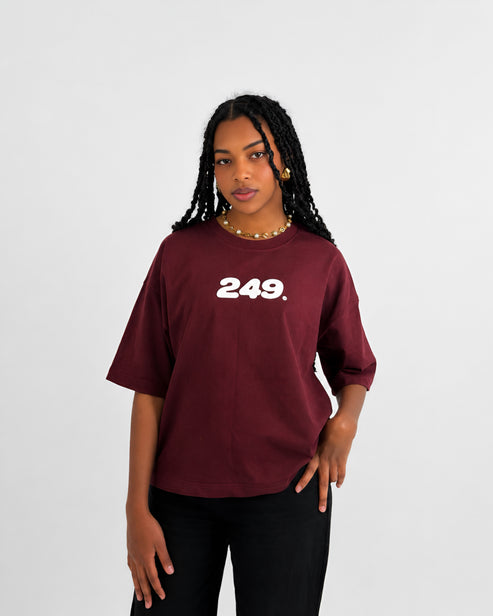

In [22]:
query_image_url = products_df.loc[0, "image_url"]

query_image = load_image_from_url(query_image_url)

display(query_image)

In [23]:
query_embedding = get_image_embedding(query_image)

query_embedding.shape

(512,)

In [26]:
from sklearn.neighbors import NearestNeighbors

image_search_model = NearestNeighbors(
    n_neighbors=3,
    metric="cosine"
)

image_search_model.fit(product_embeddings)

,n_neighbors,3
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [27]:
query_embedding = query_embedding.reshape(1, -1)

distances, indices = image_search_model.kneighbors(query_embedding)

distances, indices

(array([[0.        , 0.30460805, 0.41547483]], dtype=float32),
 array([[0, 2, 1]]))

In [28]:
image_results = products_df.iloc[indices[0]].copy()

image_results["distance"] = distances[0]

image_results[
    [
        "product_name",
        "store_name",
        "price_egp",
        "product_url",
        "distance"
    ]
]

,product_name,store_name,price_egp,product_url,distance
0,249 Code T-Shirt,balance_249,649,https://balancestudios.myshopify.com/products/...,0.000000
2,The Lace Shirt,nh_designs,799,https://nhdesignss.com/product/the-lace-shirt/,0.304608
1,Frank Ocean White T-Shirt V3,ryfworld,630,https://rockyourfits.online/products/frank-oce...,0.415475


249 Code T-Shirt
Store: balance_249
Price: 649 EGP
Distance: 0.0
Link: https://balancestudios.myshopify.com/products/249code-tshirt


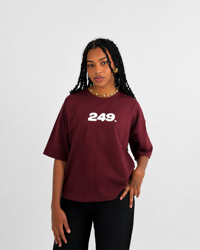

--------------------------------------------------
The Lace Shirt
Store: nh_designs
Price: 799 EGP
Distance: 0.305
Link: https://nhdesignss.com/product/the-lace-shirt/


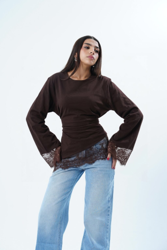

--------------------------------------------------
Frank Ocean White T-Shirt V3
Store: ryfworld
Price: 630 EGP
Distance: 0.415
Link: https://rockyourfits.online/products/frank-ocean-white-t-shirt-v3


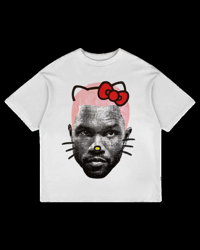

--------------------------------------------------


In [29]:
for index, row in image_results.iterrows():
    print(row["product_name"])
    print("Store:", row["store_name"])
    print("Price:", row["price_egp"], "EGP")
    print("Distance:", round(row["distance"], 3))
    print("Link:", row["product_url"])
    
    image = load_image_from_url(row["image_url"])
    
    small_image = image.copy()
    small_image.thumbnail((250, 250))
    
    display(small_image)
    
    print("-" * 50)

In [30]:
def find_similar_products(image_url, n_results=3):
    query_image = load_image_from_url(image_url)
    
    print("Query image:")
    display(query_image)
    print("-" * 50)
    
    query_embedding = get_image_embedding(query_image)
    query_embedding_2d = query_embedding.reshape(1, -1)
    
    distances, indices = image_search_model.kneighbors(
        query_embedding_2d,
        n_neighbors=n_results
    )
    
    results = products_df.iloc[indices[0]].copy()
    results["distance"] = distances[0]
    
    for index, row in results.iterrows():
        print(row["product_name"])
        print("Store:", row["store_name"])
        print("Price:", row["price_egp"], "EGP")
        print("Distance:", round(row["distance"], 3))
        print("Link:", row["product_url"])
        
        product_image = load_image_from_url(row["image_url"])
        
        small_image = product_image.copy()
        small_image.thumbnail((250, 250))
        
        display(small_image)
        print("-" * 50)
    
    return results[
        [
            "product_name",
            "store_name",
            "price_egp",
            "product_url",
            "distance"
        ]
    ]

Query image:


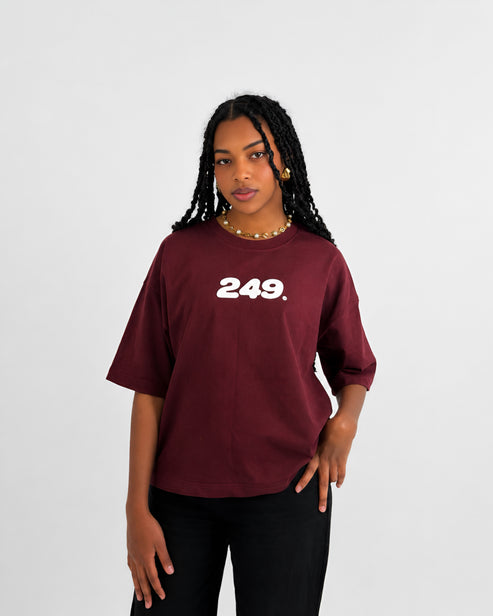

--------------------------------------------------
249 Code T-Shirt
Store: balance_249
Price: 649 EGP
Distance: 0.0
Link: https://balancestudios.myshopify.com/products/249code-tshirt


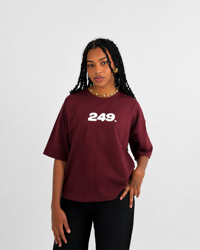

--------------------------------------------------
The Lace Shirt
Store: nh_designs
Price: 799 EGP
Distance: 0.305
Link: https://nhdesignss.com/product/the-lace-shirt/


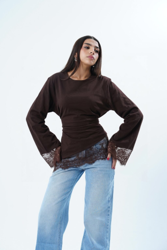

--------------------------------------------------
Frank Ocean White T-Shirt V3
Store: ryfworld
Price: 630 EGP
Distance: 0.415
Link: https://rockyourfits.online/products/frank-ocean-white-t-shirt-v3


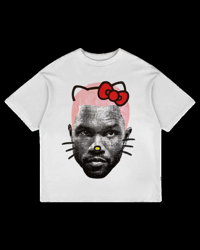

--------------------------------------------------


,product_name,store_name,price_egp,product_url,distance
0,249 Code T-Shirt,balance_249,649,https://balancestudios.myshopify.com/products/...,0.000000
2,The Lace Shirt,nh_designs,799,https://nhdesignss.com/product/the-lace-shirt/,0.304608
1,Frank Ocean White T-Shirt V3,ryfworld,630,https://rockyourfits.online/products/frank-oce...,0.415475


In [31]:
test_image_url = products_df.loc[0, "image_url"]

find_similar_products(test_image_url)

## Summary

In this notebook, I used a pretrained CLIP model to convert product images into image embeddings.  
I then used Nearest Neighbors with cosine distance to find visually similar fashion products.

The system can take an image URL, generate its embedding, compare it with product image embeddings, and return similar products with store name, price, product link, and image preview.

In [34]:
models_folder = project_root / "models"
models_folder.mkdir(exist_ok=True)

np.save(models_folder / "product_embeddings.npy", product_embeddings)

In [35]:
list(models_folder.glob("*.npy"))

[WindowsPath('c:/Users/rahaf/OneDrive/Desktop/fshn-sync/models/product_embeddings.npy')]

In [36]:
loaded_embeddings = np.load(models_folder / "product_embeddings.npy")

loaded_embeddings.shape

(3, 512)